# 0. Setup

In [1]:
import gdown

file_id = "11OtQCp4IVWiGsHo3RAMvqt2zctXrlAv2"
url = f"https://drive.google.com/uc?id={file_id}"
output_zip = "data.zip"

# Download
gdown.download(url, output_zip, quiet=False)

!unzip -q {output_zip}

Downloading...
From: https://drive.google.com/uc?id=11OtQCp4IVWiGsHo3RAMvqt2zctXrlAv2
To: /content/data.zip
100%|██████████| 1.34M/1.34M [00:00<00:00, 96.6MB/s]


# 1. Experiment

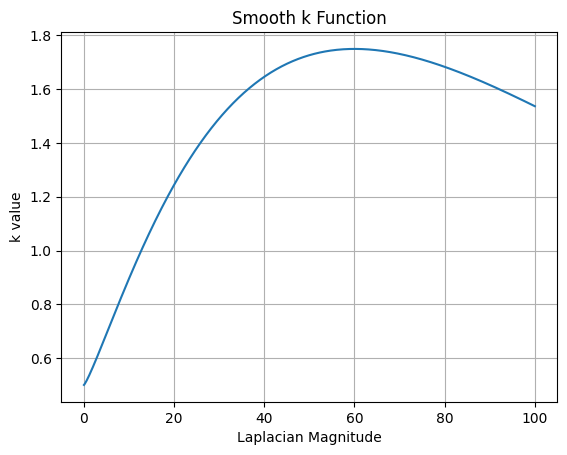

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def spatial_gain_curve(m,k_min=0.5,k_max=1.75,beta=50.0,p=1.2):
    bump = (m ** p) * np.exp(-m / beta)
    bump /= (bump.max() + 1e-8)
    k = k_min + (k_max - k_min) * bump
    return k


m = np.linspace(0, 100, 500)
k = spatial_gain_curve(m)

plt.figure()
plt.plot(m, k)
plt.title("Smooth k Function")
plt.xlabel("Laplacian Magnitude")
plt.ylabel("k value")
plt.grid(True)
plt.show()

In [2]:
import cv2

def laplacian_filter(image: np.ndarray) -> np.ndarray:
    """
    Apply the 3x3 Laplacian
    """
    h = np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ], dtype=np.float32)

    lap = np.zeros_like(image, dtype=np.float32)
    for c in range(3):
        lap[..., c] = cv2.filter2D(image[..., c].astype(np.float32), -1, h)

    return lap


def spatial_gain_rgb(laplacian: np.ndarray,
                     k_min: float = 0.5,
                     k_max: float = 1.75,
                     beta: float = 50.0,
                     p: float = 1.2) -> np.ndarray:
    magnitude = np.linalg.norm(laplacian, axis=2)
    m = magnitude / (magnitude.mean() + 1e-8)

    bump = (m ** p) * np.exp(-m / beta)
    bump /= (bump.max() + 1e-8)

    k = k_min + (k_max - k_min) * bump

    return np.repeat(k[..., None], 3, axis=2).astype(np.float32)


def high_boost(image: np.ndarray,
                   k: np.ndarray,
                   laplacian: np.ndarray) -> np.ndarray:
    """
    g = f + k * Laplacian
    """
    g = image.astype(np.float32) + k * laplacian

    g = np.clip(g, 0, 255)

    return g.astype(np.uint8)


def constant_high_boost(image: np.ndarray, k: float) -> np.ndarray:
    """
    Constant-gain RGB high-boost
    """
    lap = laplacian_filter(image)
    k_map = np.full_like(image, k, dtype=np.float32)
    return high_boost(image, k_map, lap)

In [3]:
def spatially_varying_high_boost(image_path: str,
                                              k_const: float = 1.5):
    img_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    lap = laplacian_filter(img)
    k_map = spatial_gain_rgb(lap)

    spatial_result = high_boost(img, k_map, lap)
    constant_result = constant_high_boost(img, k_const)

    return img, spatial_result, constant_result, k_map

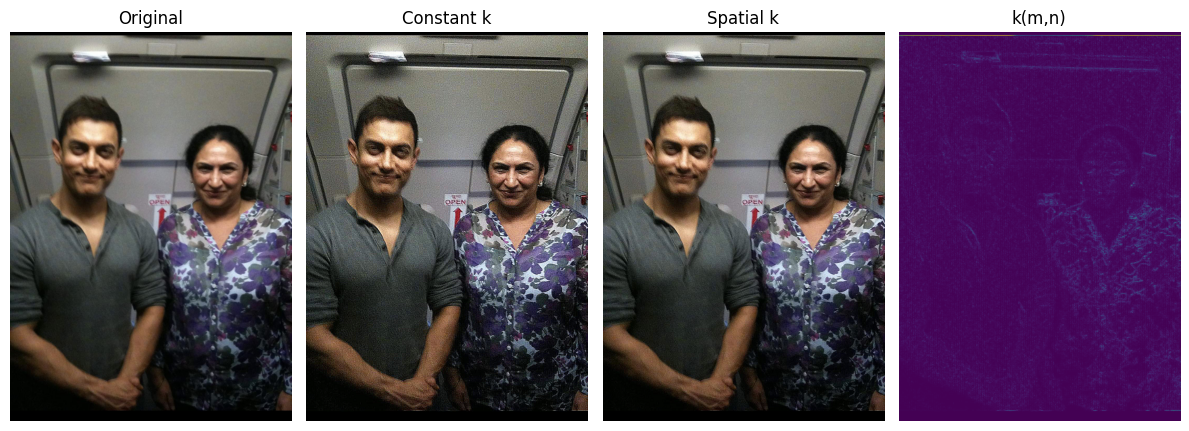

In [4]:
import matplotlib.pyplot as plt

img, spatial_res, const_res, k_map = spatially_varying_high_boost("/content/imagesforA11/FiljQr_XwAEB1qA.jpeg")

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Constant k")
plt.imshow(const_res)
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Spatial k")
plt.imshow(spatial_res)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("k(m,n)")
plt.imshow(k_map[..., 0], cmap="viridis")
plt.axis("off")

plt.tight_layout()
plt.show()

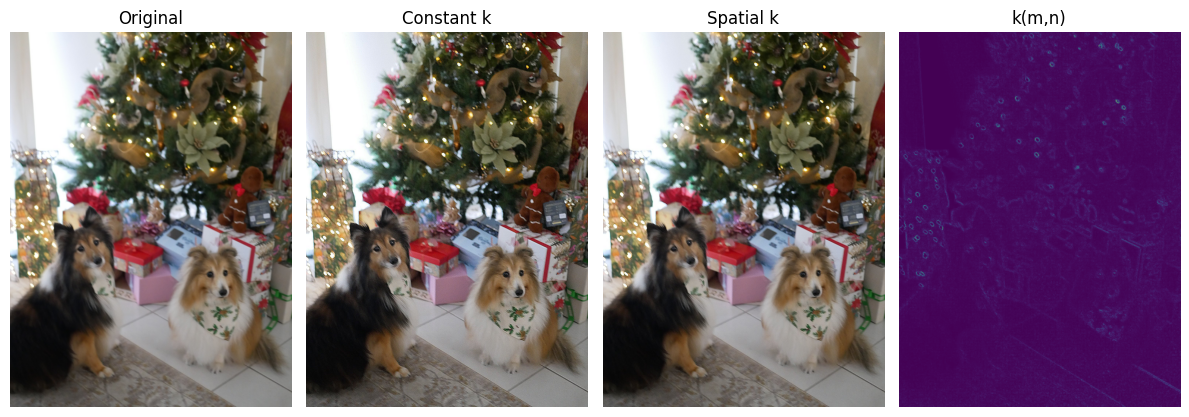

In [5]:
import matplotlib.pyplot as plt

img, spatial_res, const_res, k_map = spatially_varying_high_boost("/content/imagesforA11/FlA4ZjaagAANx_f.jpeg")

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Constant k")
plt.imshow(const_res)
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Spatial k")
plt.imshow(spatial_res)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("k(m,n)")
plt.imshow(k_map[..., 0], cmap="viridis")
plt.axis("off")

plt.tight_layout()
plt.show()

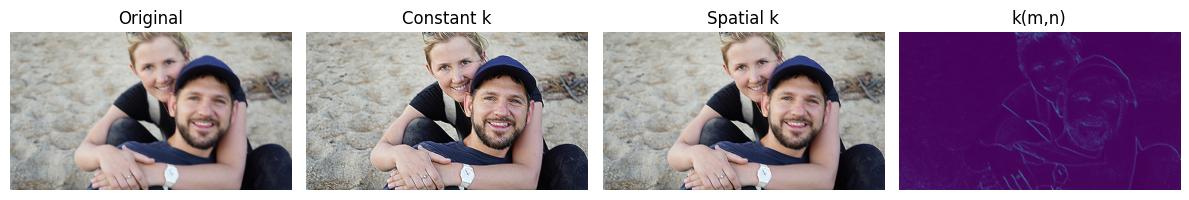

In [6]:
import matplotlib.pyplot as plt

img, spatial_res, const_res, k_map = spatially_varying_high_boost("/content/imagesforA11/Photo_Unblur_Before_KpGfyYx.max-1000x1000.png")

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Constant k")
plt.imshow(const_res)
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Spatial k")
plt.imshow(spatial_res)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("k(m,n)")
plt.imshow(k_map[..., 0], cmap="viridis")
plt.axis("off")

plt.tight_layout()
plt.show()